In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict

from surprise import Dataset, Reader, KNNBasic, accuracy
from surprise.model_selection import cross_validate, KFold
from surprise import AlgoBase, PredictionImpossible

plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:

ratings_df = pd.read_csv('movies/ratings_small.csv')
print(ratings_df.shape)
print(ratings_df.dtypes)
ratings_df.head()

(100004, 4)
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [30]:
print('Rating range:', ratings_df['rating'].min(), '–', ratings_df['rating'].max())
print('Unique users:', ratings_df['userId'].nunique())
print('Unique movies:', ratings_df['movieId'].nunique())
print('Total ratings:', len(ratings_df))

# Surprise Reader — specify the rating scale
reader = Reader(rating_scale=(ratings_df['rating'].min(), ratings_df['rating'].max()))

# Load into Surprise Dataset (userId, movieId, rating)
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)
print('\nSurprise dataset loaded.')

Rating range: 0.5 – 5.0
Unique users: 671
Unique movies: 9066
Total ratings: 100004

Surprise dataset loaded.


In [31]:
class PMF(AlgoBase):
    def __init__(self, n_factors=20, n_epochs=50, lr=0.005, reg=0.02):
        AlgoBase.__init__(self)
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        self.pu = np.random.normal(0, 0.1, (trainset.n_users, self.n_factors))
        self.qi = np.random.normal(0, 0.1, (trainset.n_items, self.n_factors))
        for _ in range(self.n_epochs):
            for u, i, r in trainset.all_ratings():
                err = r - np.dot(self.pu[u], self.qi[i])
                self.pu[u] += self.lr * (err * self.qi[i] - self.reg * self.pu[u])
                self.qi[i] += self.lr * (err * self.pu[u] - self.reg * self.qi[i])
        return self

    def estimate(self, u, i):
        if not (self.trainset.knows_user(u) and self.trainset.knows_item(i)):
            raise PredictionImpossible('User or item is unknown.')
        return np.dot(self.pu[u], self.qi[i])

In [32]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)

MODELS = {
    'PMF'    : PMF(n_factors=20, n_epochs=50, lr=0.005, reg=0.02),
    'User-CF': KNNBasic(sim_options={'name': 'cosine', 'user_based': True}),
    'Item-CF': KNNBasic(sim_options={'name': 'cosine', 'user_based': False}),
}

cv_results_c = {}
for model_name, algo in MODELS.items():
    print(f'Cross-validating {model_name} ...')
    cv_out = cross_validate(
        algo, data,
        measures=['RMSE', 'MAE'],
        cv=kf,
        verbose=False
    )
    mean_rmse = cv_out['test_rmse'].mean()
    mean_mae  = cv_out['test_mae'].mean()
    cv_results_c[model_name] = {'RMSE': mean_rmse, 'MAE': mean_mae, 'raw': cv_out}
    print(f'  Mean RMSE = {mean_rmse:.4f}  |  Mean MAE = {mean_mae:.4f}\n')

Cross-validating PMF ...
  Mean RMSE = 0.9645  |  Mean MAE = 0.7410

Cross-validating User-CF ...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  Mean RMSE = 0.9931  |  Mean MAE = 0.7671

Cross-validating Item-CF ...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  Mean RMSE = 0.9951  |  Mean MAE = 0.7748



In [33]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)

MODELS = {
    'PMF': SVD(biased=False, random_state=42),
    'User-CF'  : KNNBasic(sim_options={'name': 'cosine', 'user_based': True}),
    'Item-CF'  : KNNBasic(sim_options={'name': 'cosine', 'user_based': False}),
}

cv_results_c = {}
for model_name, algo in MODELS.items():
    print(f'Cross-validating {model_name} ...')
    cv_out = cross_validate(
        algo, data,
        measures=['RMSE', 'MAE'],
        cv=kf,
        verbose=False
    )
    mean_rmse = cv_out['test_rmse'].mean()
    mean_mae  = cv_out['test_mae'].mean()
    cv_results_c[model_name] = {'RMSE': mean_rmse, 'MAE': mean_mae, 'raw': cv_out}
    print(f'  Mean RMSE = {mean_rmse:.4f}  |  Mean MAE = {mean_mae:.4f}\n')

Cross-validating PMF ...
  Mean RMSE = 1.0130  |  Mean MAE = 0.7803

Cross-validating User-CF ...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  Mean RMSE = 0.9931  |  Mean MAE = 0.7671

Cross-validating Item-CF ...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  Mean RMSE = 0.9951  |  Mean MAE = 0.7748



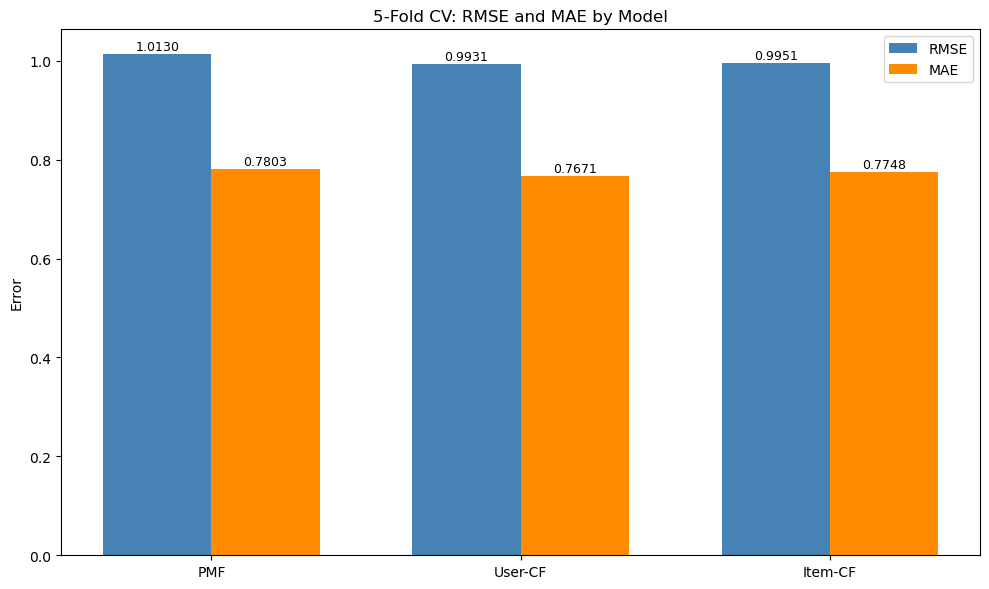

In [34]:
model_names = list(cv_results_c.keys())
rmse_vals   = [cv_results_c[m]['RMSE'] for m in model_names]
mae_vals    = [cv_results_c[m]['MAE']  for m in model_names]

x   = np.arange(len(model_names))
w   = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='steelblue')
b2 = ax.bar(x + w/2, mae_vals,  w, label='MAE',  color='darkorange')

ax.set_title('5-Fold CV: RMSE and MAE by Model')
ax.set_ylabel('Error')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('partc_model_comparison.png', dpi=150)
plt.show()

Part e Impact of Similarity Metric (Cosine, MSD, Pearson) on User-CF and Item-CF

In [35]:
SIMILARITY_METRICS = ['cosine', 'msd', 'pearson']
CF_TYPES = {
    'User-CF': True,   # user_based=True
    'Item-CF': False,  # user_based=False
}

results_e = {cf: {sim: {} for sim in SIMILARITY_METRICS} for cf in CF_TYPES}

for cf_name, user_based in CF_TYPES.items():
    for sim in SIMILARITY_METRICS:
        print(f'{cf_name} | similarity={sim} ...', end=' ')
        algo = KNNBasic(sim_options={'name': sim, 'user_based': user_based})
        cv_out = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=kf, verbose=False)
        results_e[cf_name][sim] = {
            'RMSE': cv_out['test_rmse'].mean(),
            'MAE' : cv_out['test_mae'].mean(),
        }
        print(f'RMSE={results_e[cf_name][sim]["RMSE"]:.4f}  MAE={results_e[cf_name][sim]["MAE"]:.4f}')

User-CF | similarity=cosine ... Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE=0.9931  MAE=0.7671
User-CF | similarity=msd ... Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE=0.9678  MAE=0.7437
User-CF | similarity=pearson ... Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity mat

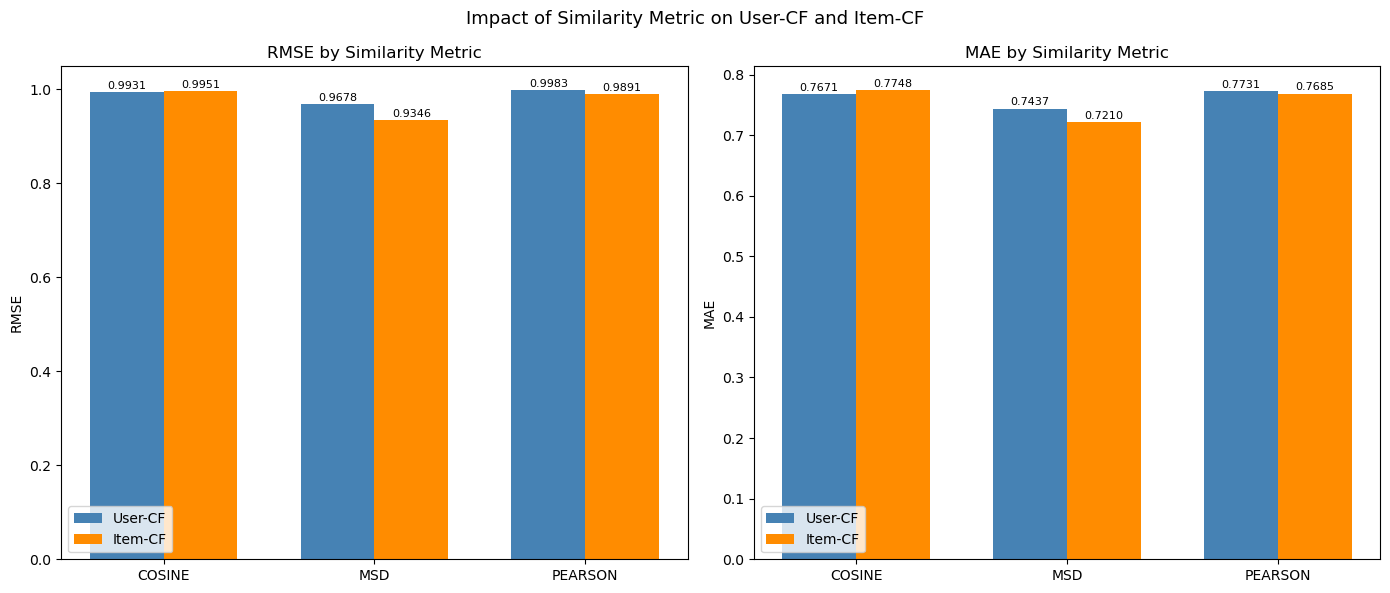

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

x = np.arange(len(SIMILARITY_METRICS))
w = 0.35
colors_cf = ['steelblue', 'darkorange']

for metric_idx, metric in enumerate(['RMSE', 'MAE']):
    ax = axes[metric_idx]
    for cf_idx, cf_name in enumerate(CF_TYPES):
        vals = [results_e[cf_name][sim][metric] for sim in SIMILARITY_METRICS]
        offset = (cf_idx - 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=cf_name, color=colors_cf[cf_idx])
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    f'{bar.get_height():.4f}',
                    ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{metric} by Similarity Metric')
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in SIMILARITY_METRICS])
    ax.legend()

plt.suptitle('Impact of Similarity Metric on User-CF and Item-CF', fontsize=13)
plt.tight_layout()
plt.savefig('parte_similarity_impact.png', dpi=150)
plt.show()

Part f Impact of Number of Neighbors K

In [37]:
# Sweep K from 5 to 100 in steps of 5
K_VALUES   = list(range(5, 105, 5))
BEST_SIM   = 'msd'   # use best similarity from Part e (adjust if needed)

results_f = {'User-CF': {'RMSE': [], 'MAE': []},
             'Item-CF': {'RMSE': [], 'MAE': []}}

print(f'Sweeping K ∈ {K_VALUES} with similarity={BEST_SIM} ...')
for k_val in K_VALUES:
    for cf_name, user_based in CF_TYPES.items():
        algo = KNNBasic(
            k=k_val,
            sim_options={'name': BEST_SIM, 'user_based': user_based}
        )
        cv_out = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=kf, verbose=False)
        results_f[cf_name]['RMSE'].append(cv_out['test_rmse'].mean())
        results_f[cf_name]['MAE'].append(cv_out['test_mae'].mean())
    print(f'  K={k_val:3d}  User-CF RMSE={results_f["User-CF"]["RMSE"][-1]:.4f}  '
          f'Item-CF RMSE={results_f["Item-CF"]["RMSE"][-1]:.4f}')

Sweeping K ∈ [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100] with similarity=msd ...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  K=  5  User-CF RMSE=0.9863  Item-CF RMSE=1.0220
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity 

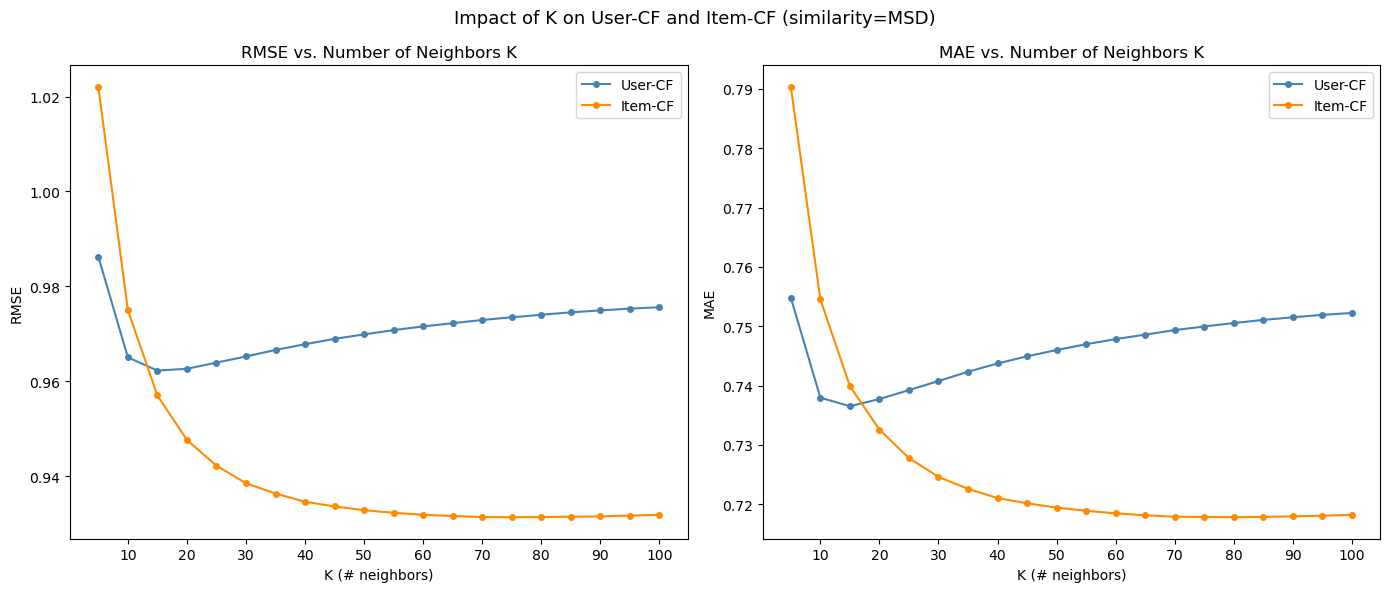

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for metric_idx, metric in enumerate(['RMSE', 'MAE']):
    ax = axes[metric_idx]
    for cf_name, color in zip(CF_TYPES, colors_cf):
        ax.plot(K_VALUES, results_f[cf_name][metric], marker='o', ms=4,
                label=cf_name, color=color)
    ax.set_title(f'{metric} vs. Number of Neighbors K')
    ax.set_xlabel('K (# neighbors)')
    ax.set_ylabel(metric)
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))

plt.suptitle(f'Impact of K on User-CF and Item-CF (similarity={BEST_SIM.upper()})', fontsize=13)
plt.tight_layout()
plt.savefig('partf_k_impact.png', dpi=150)
plt.show()

Part g Best K for User-CF and Item-CF (by RMSE)

In [40]:
best_k_user = K_VALUES[np.argmin(results_f['User-CF']['RMSE'])]
best_k_item = K_VALUES[np.argmin(results_f['Item-CF']['RMSE'])]

best_rmse_user = min(results_f['User-CF']['RMSE'])
best_rmse_item = min(results_f['Item-CF']['RMSE'])

print(f'Best K for User-CF: K={best_k_user}  (RMSE={best_rmse_user:.4f})')
print(f'Best K for Item-CF: K={best_k_item}  (RMSE={best_rmse_item:.4f})')

if best_k_user == best_k_item:
    print(f'\nConclusion: The best K is the SAME for User-CF and Item-CF (K={best_k_user}).')
else:
    print(f'\nConclusion: The best K DIFFERS — User-CF prefers K={best_k_user}, Item-CF prefers K={best_k_item}.')

Best K for User-CF: K=15  (RMSE=0.9622)
Best K for Item-CF: K=75  (RMSE=0.9313)

Conclusion: The best K DIFFERS — User-CF prefers K=15, Item-CF prefers K=75.


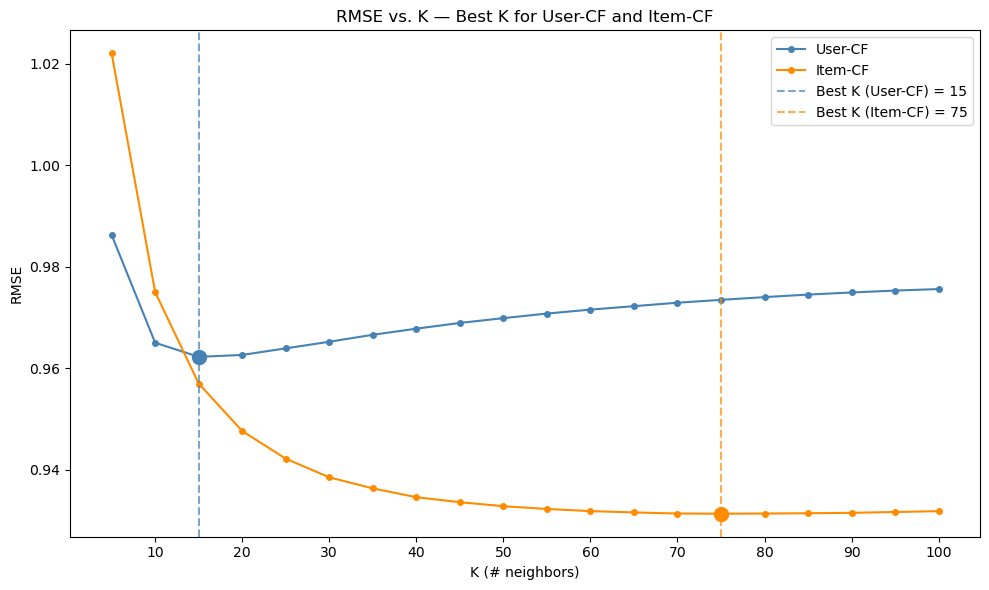

In [41]:
# Plot with best-K markers
fig, ax = plt.subplots(figsize=(10, 6))

for cf_name, color in zip(CF_TYPES, colors_cf):
    ax.plot(K_VALUES, results_f[cf_name]['RMSE'], marker='o', ms=4, label=cf_name, color=color)

ax.axvline(best_k_user, color='steelblue',  linestyle='--', alpha=0.7,
           label=f'Best K (User-CF) = {best_k_user}')
ax.axvline(best_k_item, color='darkorange', linestyle='--', alpha=0.7,
           label=f'Best K (Item-CF) = {best_k_item}')

ax.scatter([best_k_user], [best_rmse_user], color='steelblue',  s=100, zorder=5)
ax.scatter([best_k_item], [best_rmse_item], color='darkorange', s=100, zorder=5)

ax.set_title(f'RMSE vs. K — Best K for User-CF and Item-CF')
ax.set_xlabel('K (# neighbors)')
ax.set_ylabel('RMSE')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))

plt.tight_layout()
plt.savefig('partg_best_k.png', dpi=150)
plt.show()